# Q2.7 Best Model Evaluation

Create an overlay plot of training vs test accuracy across all hyperparameter-search runs, identify high-train/low-test runs.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import wandb

ENTITY = 'anandhakrishnanm21-indian-institute-of-technology-madras'
SWEEP_PROJECT = 'q2_2_sweep_mnist'

In [ ]:
api = wandb.Api()
runs = api.runs(f'{ENTITY}/{SWEEP_PROJECT}')

rows = []
for r in runs:
    s = r.summary
    train_acc, test_acc = s.get('train_acc'), s.get('test_acc')
    if train_acc is None or test_acc is None:
        continue
    rows.append({
        'run_name': r.name,
        'run_id': r.id,
        'train_acc': float(train_acc),
        'test_acc': float(test_acc),
        'gap': float(train_acc) - float(test_acc),
        'best_val_f1': float(s.get('best_val_f1')) if s.get('best_val_f1') is not None else np.nan,
    })

if not rows:
    raise RuntimeError('No runs with both train_acc and test_acc were found in the sweep project.')

rows.sort(key=lambda x: x['train_acc'], reverse=True)
print(f'Loaded {len(rows)} runs from {ENTITY}/{SWEEP_PROJECT}')


Loaded 100 runs from anandhakrishnanm21-indian-institute-of-technology-madras/q2_2_sweep_mnist


[{'run_name': 'sweep_mnist',
  'run_id': 'l3vzy521',
  'train_acc': 1.0,
  'test_acc': 0.9818,
  'gap': 0.018199999999999994,
  'best_val_f1': 0.9824046992551424},
 {'run_name': 'sweep_mnist',
  'run_id': '0zg0fabj',
  'train_acc': 0.999462962962963,
  'test_acc': 0.9794,
  'gap': 0.02006296296296295,
  'best_val_f1': 0.9776621710209934},
 {'run_name': 'sweep_mnist',
  'run_id': '5xfohoxq',
  'train_acc': 0.999074074074074,
  'test_acc': 0.9789,
  'gap': 0.02017407407407401,
  'best_val_f1': 0.9774796525015012},
 {'run_name': 'sweep_mnist',
  'run_id': 'skt5wuy0',
  'train_acc': 0.9989444444444444,
  'test_acc': 0.9766,
  'gap': 0.02234444444444439,
  'best_val_f1': 0.9773572738945931},
 {'run_name': 'sweep_mnist',
  'run_id': 'w8dx3l6l',
  'train_acc': 0.9975,
  'test_acc': 0.9763,
  'gap': 0.021200000000000108,
  'best_val_f1': 0.9741215350635936},
 {'run_name': 'sweep_mnist',
  'run_id': '0502a5yb',
  'train_acc': 0.9972962962962963,
  'test_acc': 0.9759,
  'gap': 0.0213962962962963

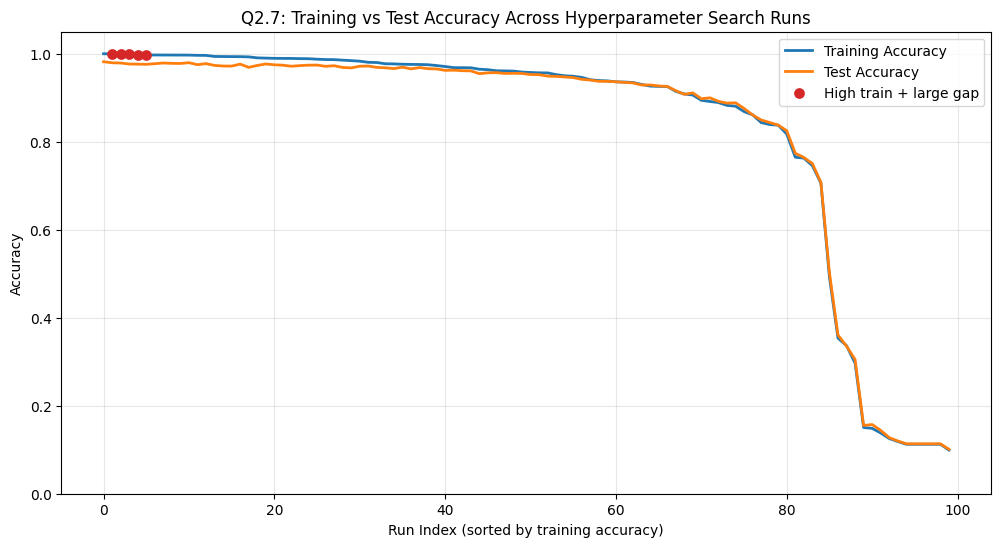

High-train threshold (90th pct): 0.9969
Large-gap threshold (90th pct): 0.0199
Potential overfitting runs found: 5


[{'run_name': 'sweep_mnist',
  'run_id': 'skt5wuy0',
  'train_acc': 0.9989444444444444,
  'test_acc': 0.9766,
  'gap': 0.02234444444444439,
  'best_val_f1': 0.9773572738945931},
 {'run_name': 'sweep_mnist',
  'run_id': '0502a5yb',
  'train_acc': 0.9972962962962963,
  'test_acc': 0.9759,
  'gap': 0.021396296296296358,
  'best_val_f1': 0.9763960308118532},
 {'run_name': 'sweep_mnist',
  'run_id': 'w8dx3l6l',
  'train_acc': 0.9975,
  'test_acc': 0.9763,
  'gap': 0.021200000000000108,
  'best_val_f1': 0.9741215350635936},
 {'run_name': 'sweep_mnist',
  'run_id': '5xfohoxq',
  'train_acc': 0.999074074074074,
  'test_acc': 0.9789,
  'gap': 0.02017407407407401,
  'best_val_f1': 0.9774796525015012},
 {'run_name': 'sweep_mnist',
  'run_id': '0zg0fabj',
  'train_acc': 0.999462962962963,
  'test_acc': 0.9794,
  'gap': 0.02006296296296295,
  'best_val_f1': 0.9776621710209934}]

In [8]:
train_acc = np.array([r['train_acc'] for r in rows])
test_acc = np.array([r['test_acc'] for r in rows])
gap = train_acc - test_acc

high_train_threshold = np.quantile(train_acc, 0.90)
large_gap_threshold = np.quantile(gap, 0.90)
overfit_idx = np.where((train_acc >= high_train_threshold) & (gap >= large_gap_threshold))[0]

x = np.arange(len(rows))
plt.figure(figsize=(12, 6))
plt.plot(x, train_acc, label='Training Accuracy', linewidth=2)
plt.plot(x, test_acc, label='Test Accuracy', linewidth=2)

if len(overfit_idx):
    plt.scatter(overfit_idx, train_acc[overfit_idx], c='tab:red', s=45, label='High train + large gap', zorder=3)

plt.title('Q2.7: Training vs Test Accuracy Across Hyperparameter Search Runs')
plt.xlabel('Run Index (sorted by training accuracy)')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f'High-train threshold (90th pct): {high_train_threshold:.4f}')
print(f'Large-gap threshold (90th pct): {large_gap_threshold:.4f}')
print(f'Potential overfitting runs found: {len(overfit_idx)}')

overfit_rows = sorted((rows[i] for i in overfit_idx), key=lambda r: r['gap'], reverse=True)[:15]
[{k: r[k] for k in ('run_name', 'run_id', 'train_acc', 'test_acc', 'gap', 'best_val_f1')} for r in overfit_rows]


### Interpretation
A large **train-test accuracy gap** means the model fit the training data much better than unseen data.

This indicates **overfitting** (poor generalization), typically caused by combinations like high model capacity and/or overly aggressive training hyperparameters and large number of training epochs.
